In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Load dataset

In [90]:
DATA_PATH=Path('data/NYC.csv')
df=pd.read_csv(DATA_PATH)
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.98,40.77,-73.96,40.77,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.98,40.74,-74.00,40.73,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.98,40.76,-74.01,40.71,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.01,40.72,-74.01,40.71,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.97,40.79,-73.97,40.78,N,435
...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.98,40.75,-73.99,40.74,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.00,40.75,-73.97,40.80,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.96,40.77,-74.00,40.71,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.98,40.75,-73.97,40.76,N,373


## Basic info about dataset 

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


In [92]:
df.head(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.98,40.77,-73.96,40.77,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.98,40.74,-74.00,40.73,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.98,40.76,-74.01,40.71,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.01,40.72,-74.01,40.71,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.97,40.79,-73.97,40.78,N,435


In [93]:
df.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
467106,id3016842,1,2016-02-02 22:09:31,2016-02-02 22:14:32,1,-73.97,40.76,-73.97,40.77,N,301
765659,id2159041,2,2016-03-20 02:33:29,2016-03-20 02:39:32,2,-73.99,40.72,-73.98,40.73,N,363
693659,id2658019,1,2016-01-21 13:16:04,2016-01-21 13:34:56,1,-73.95,40.78,-73.98,40.77,N,1132
114023,id1348104,2,2016-03-20 18:27:25,2016-03-20 18:31:54,1,-73.98,40.75,-73.99,40.74,N,269
1201644,id2923840,1,2016-06-22 17:05:53,2016-06-22 17:15:01,1,-74.00,40.73,-73.99,40.72,N,548


In [94]:
df.shape

(1458644, 11)

In [95]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1458644.00,1458644.00,1458644.00,1458644.00,1458644.00,1458644.00,1458644.00
mean,1.53,1.66,-73.97,40.75,-73.97,40.75,959.49
std,0.50,1.31,0.07,0.03,0.07,0.04,5237.43
min,1.00,0.00,-121.93,34.36,-121.93,32.18,1.00
25%,1.00,1.00,-73.99,40.74,-73.99,40.74,397.00
50%,2.00,1.00,-73.98,40.75,-73.98,40.75,662.00
75%,2.00,2.00,-73.97,40.77,-73.96,40.77,1075.00
max,2.00,9.00,-61.34,51.88,-61.34,43.92,3526282.00


In [96]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [97]:
df.select_dtypes(include='str')

,id,pickup_datetime,dropoff_datetime,store_and_fwd_flag
0,id2875421,2016-03-14 17:24:55,2016-03-14 17:32:30,N
1,id2377394,2016-06-12 00:43:35,2016-06-12 00:54:38,N
2,id3858529,2016-01-19 11:35:24,2016-01-19 12:10:48,N
3,id3504673,2016-04-06 19:32:31,2016-04-06 19:39:40,N
4,id2181028,2016-03-26 13:30:55,2016-03-26 13:38:10,N
...,...,...,...,...
1458639,id2376096,2016-04-08 13:31:04,2016-04-08 13:44:02,N
1458640,id1049543,2016-01-10 07:35:15,2016-01-10 07:46:10,N
1458641,id2304944,2016-04-22 06:57:41,2016-04-22 07:10:25,N
1458642,id2714485,2016-01-05 15:56:26,2016-01-05 16:02:39,N


In [98]:
df.select_dtypes(include='number')

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
0,2,1,-73.98,40.77,-73.96,40.77,455
1,1,1,-73.98,40.74,-74.00,40.73,663
2,2,1,-73.98,40.76,-74.01,40.71,2124
3,2,1,-74.01,40.72,-74.01,40.71,429
4,2,1,-73.97,40.79,-73.97,40.78,435
...,...,...,...,...,...,...,...
1458639,2,4,-73.98,40.75,-73.99,40.74,778
1458640,1,1,-74.00,40.75,-73.97,40.80,655
1458641,2,1,-73.96,40.77,-74.00,40.71,764
1458642,1,1,-73.98,40.75,-73.97,40.76,373


In [99]:
df=df.drop(columns='dropoff_datetime')

## Target variable

<Axes: xlabel='trip_duration', ylabel='Count'>

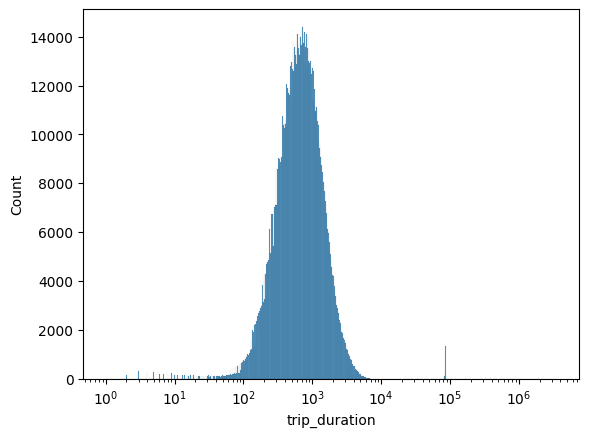

In [100]:
sns.histplot(data=df,x='trip_duration',log_scale=True)

In [101]:
Q1=df['trip_duration'].quantile(0.25)
Q3=df['trip_duration'].quantile(0.75)
IQR=Q3-Q1
upper_bound = Q3 + 3 * IQR
print(upper_bound)

3109.0


In [102]:
df['trip_duration'].mean()

np.float64(959.4922729603659)

In [103]:
df['trip_duration'].median()


np.float64(662.0)

In [104]:
df[df['trip_duration'] < 60]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
72,id1510700,2,2016-02-20 21:58:13,1,-73.96,40.77,-73.96,40.77,N,57
323,id2954399,1,2016-06-27 11:22:37,1,-74.00,40.76,-74.00,40.76,N,40
842,id3263580,2,2016-05-21 12:46:46,2,-73.78,40.65,-73.78,40.65,N,3
853,id2730154,2,2016-03-29 22:39:46,5,-73.98,40.73,-73.98,40.73,N,58
1107,id0729156,2,2016-06-23 13:36:48,3,-73.83,40.72,-73.82,40.71,N,2
...,...,...,...,...,...,...,...,...,...,...
1458044,id3200588,2,2016-03-12 01:35:35,1,-74.01,40.74,-74.01,40.74,N,7
1458085,id1326136,2,2016-05-21 12:07:11,1,-73.98,40.76,-73.98,40.76,N,17
1458140,id0175875,1,2016-03-22 06:18:10,1,-73.99,40.74,-73.99,40.75,N,37
1458544,id3958653,1,2016-06-16 15:10:11,1,-73.96,40.77,-73.96,40.77,N,38


In [105]:
df[df['trip_duration'] > 15000]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
531,id3307903,2,2016-02-20 04:03:06,3,-74.01,40.74,-74.01,40.71,N,84594
1134,id1091477,2,2016-05-07 18:36:22,1,-73.99,40.75,-73.98,40.75,N,86149
1865,id3431345,2,2016-06-07 12:58:48,6,-73.95,40.78,-73.98,40.74,N,86352
3442,id1487069,2,2016-02-13 00:21:49,1,-73.97,40.80,-73.98,40.78,N,86236
4172,id3674870,2,2016-03-18 11:54:20,1,-73.99,40.74,-73.97,40.75,N,85197
...,...,...,...,...,...,...,...,...,...,...
1455097,id2798196,2,2016-03-20 03:51:36,2,-73.97,40.76,-73.87,40.71,N,72504
1456458,id2055880,2,2016-02-08 19:11:31,3,-73.97,40.76,-73.99,40.76,N,86233
1457207,id1910950,2,2016-06-08 16:29:12,1,-73.96,40.80,-73.96,40.81,N,85311
1457752,id1215198,2,2016-02-02 11:31:10,6,-73.97,40.79,-73.96,40.81,N,86314


## Delete invalid trip duration (if a trip less or equal 60s and more or eqaul 2:30 hours)

In [106]:
df=df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 9000)]

## Pickup_date -> hour, day_of_week,month

In [107]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [108]:
df['hour']=df['pickup_datetime'].dt.hour

In [109]:
df['day_of_week']=df['pickup_datetime'].dt.day_of_week

In [110]:
df['month']=df['pickup_datetime'].dt.month

In [111]:
df

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month
0,id2875421,2,2016-03-14 17:24:55,1,-73.98,40.77,-73.96,40.77,N,455,17,0,3
1,id2377394,1,2016-06-12 00:43:35,1,-73.98,40.74,-74.00,40.73,N,663,0,6,6
2,id3858529,2,2016-01-19 11:35:24,1,-73.98,40.76,-74.01,40.71,N,2124,11,1,1
3,id3504673,2,2016-04-06 19:32:31,1,-74.01,40.72,-74.01,40.71,N,429,19,2,4
4,id2181028,2,2016-03-26 13:30:55,1,-73.97,40.79,-73.97,40.78,N,435,13,5,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,4,-73.98,40.75,-73.99,40.74,N,778,13,4,4
1458640,id1049543,1,2016-01-10 07:35:15,1,-74.00,40.75,-73.97,40.80,N,655,7,6,1
1458641,id2304944,2,2016-04-22 06:57:41,1,-73.96,40.77,-74.00,40.71,N,764,6,4,4
1458642,id2714485,1,2016-01-05 15:56:26,1,-73.98,40.75,-73.97,40.76,N,373,15,1,1


## Target variable plots 

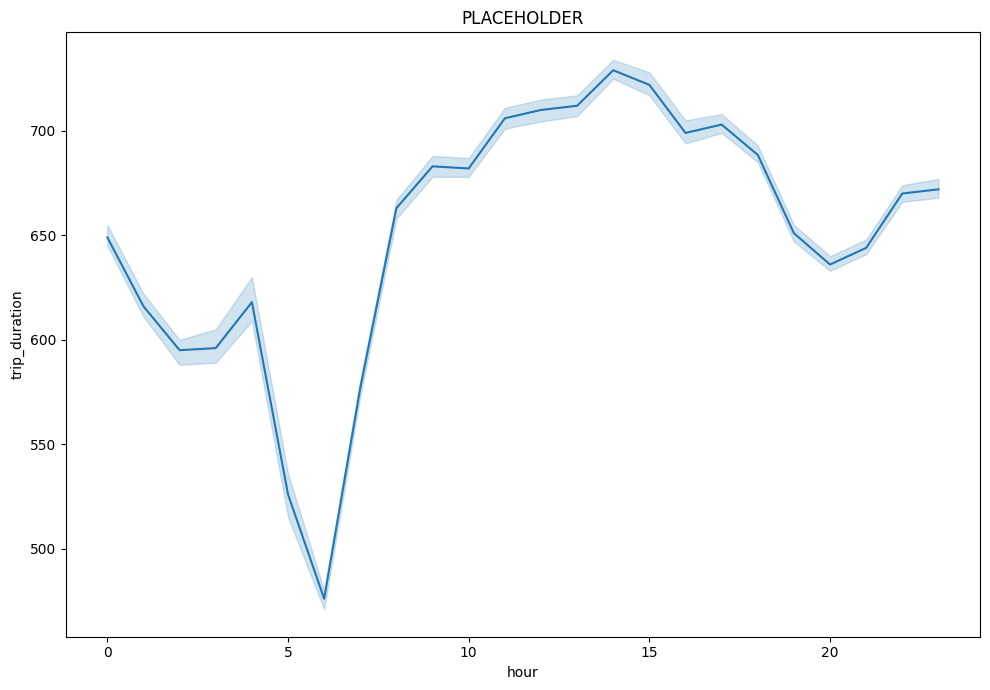

In [112]:
plt.figure(figsize=(10,7))
sns.lineplot(data=df,x='hour',y='trip_duration',estimator='median')
plt.title("PLACEHOLDER")
plt.tight_layout()
plt.show()

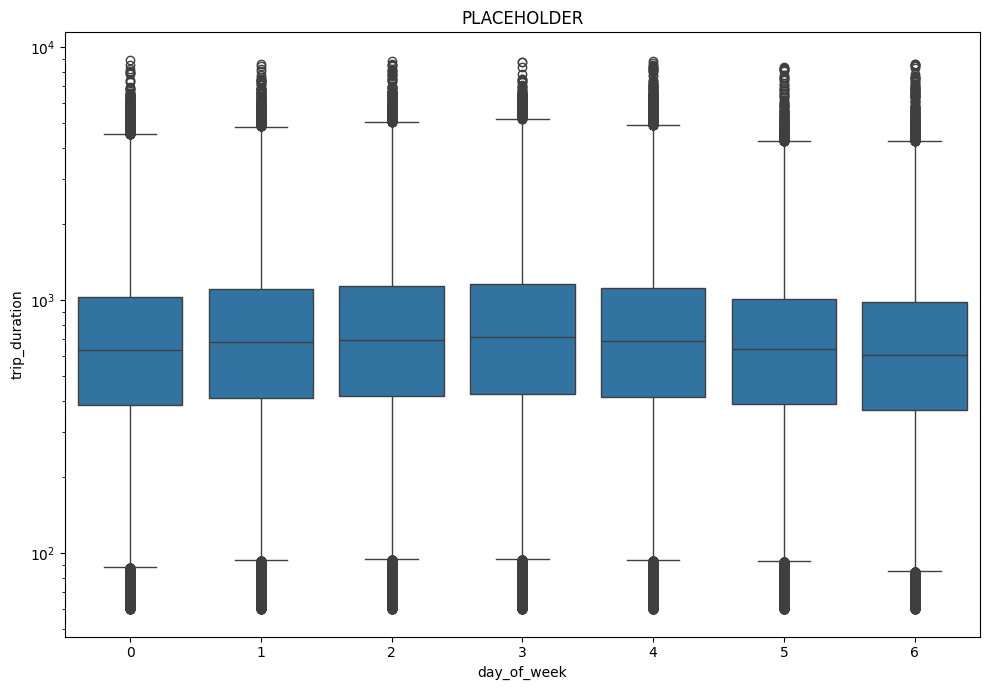

In [113]:
plt.figure(figsize=(10,7))
sns.boxplot(data=df,x='day_of_week',y='trip_duration',log_scale=True)
plt.title("PLACEHOLDER")
plt.tight_layout()
plt.show()

In [114]:
heatmap_data=df.groupby(['day_of_week','hour'])['trip_duration'].median().unstack()

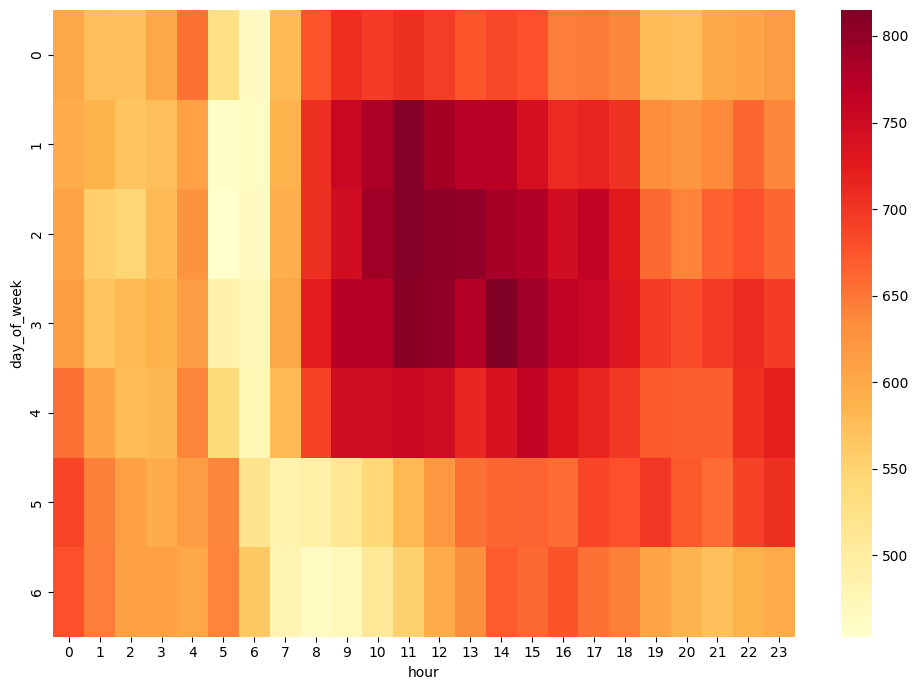

In [115]:
plt.figure(figsize=(10,7))
sns.heatmap(data=heatmap_data,cmap='YlOrRd')
plt.tight_layout()
plt.show()

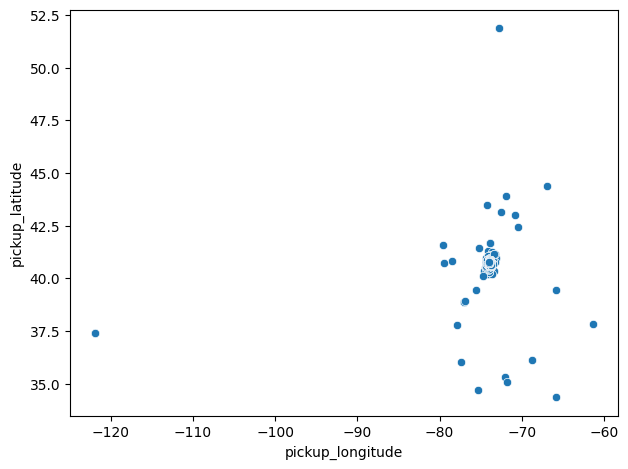

In [116]:
sns.scatterplot(data=df, x='pickup_longitude',y='pickup_latitude')
plt.tight_layout()
plt.show()

In [117]:
limit_df = df.sample(10000)

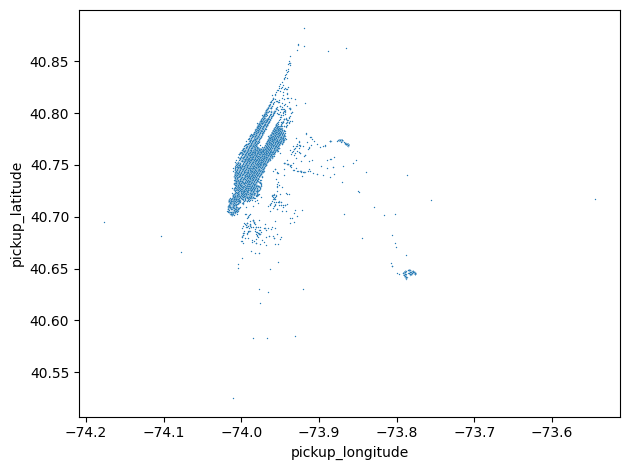

In [118]:
sns.scatterplot(data=limit_df, x='pickup_longitude',y='pickup_latitude',s=1)
plt.tight_layout()
plt.show()

In [119]:
print(f'Pick up latitude mean: {df['pickup_latitude'].mean()}')
print(f'Pick up latitude median: {df['pickup_latitude'].median()}')
print(f'Drop off latitude mean: {df['dropoff_latitude'].mean()}')
print(f'Dropoff latitude median: {df['dropoff_latitude'].median()}')


Pick up latitude mean: 40.75097084978203
Pick up latitude median: 40.75413131713867
Drop off latitude mean: 40.751849959807416
Dropoff latitude median: 40.754558563232415


In [120]:
print(f'Pick up longitude mean: {df['pickup_longitude'].mean()}')
print(f'Pick up longitude median: {df['pickup_longitude'].median()}')
print(f'Drop off longitude mean: {df['dropoff_longitude'].mean()}')
print(f'Dropoff longitude median: {df['dropoff_longitude'].median()}')

Pick up longitude mean: -73.97361827438661
Pick up longitude median: -73.9817657470703
Drop off longitude mean: -73.97354421320041
Dropoff longitude median: -73.97976684570312


In [121]:
df[(df['pickup_longitude']==df['dropoff_longitude']) & (df['pickup_latitude']==df['dropoff_latitude'])]

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,month
246,id3487442,2,2016-02-29 18:39:12,1,-73.98,40.77,-73.98,40.77,N,227,18,0,2
291,id0924324,2,2016-05-10 18:07:52,2,-73.96,40.78,-73.96,40.78,N,1109,18,1,5
407,id1145809,2,2016-05-16 23:15:13,6,-73.81,40.69,-73.81,40.69,N,947,23,0,5
702,id3499387,1,2016-01-25 19:45:12,1,-73.79,40.65,-73.79,40.65,N,580,19,0,1
1769,id2892749,1,2016-01-18 15:24:43,5,-73.95,40.82,-73.95,40.82,Y,254,15,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456399,id0618137,2,2016-02-17 08:57:04,1,-73.98,40.76,-73.98,40.76,N,1284,8,2,2
1456627,id1048767,2,2016-02-06 22:01:40,1,-73.96,40.77,-73.96,40.77,N,127,22,5,2
1456989,id2595295,2,2016-03-12 07:37:16,1,-73.98,40.73,-73.98,40.73,N,566,7,5,3
1457114,id0051314,2,2016-04-09 20:34:21,1,-73.97,40.77,-73.97,40.77,N,632,20,5,4


In [122]:
df = df[~((df['pickup_longitude'] == df['dropoff_longitude']) & (df['pickup_latitude'] == df['dropoff_latitude']))]

In [123]:
df=df[(df['pickup_longitude'].between(-74.5,-73)) & (df['dropoff_longitude'].between(-74.5,-73)) & (df["dropoff_latitude"].between(40, 41)) & (df["pickup_latitude"].between(40, 41))]

In [124]:
lat1, lng1, lat2, lng2 = map(np.radians, (df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude']))
AVG_EARTH_RADIUS = 6371
lat = lat2 - lat1
lng = lng2 - lng1
d = np.sin(lat * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5) ** 2
h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))

h

0         1.50
1         1.81
2         6.39
3         1.49
4         1.19
          ... 
1458639   1.23
1458640   6.05
1458641   7.82
1458642   1.09
1458643   1.13
Length: 1443446, dtype: float64

In [125]:
df['speed_kmh'] = h / (df['trip_duration'] / 3600)

In [126]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [127]:
df['speed_kmh'].describe()

count   1443446.00
mean         14.45
std           7.71
min           0.00
25%           9.20
50%          12.84
75%          17.87
max         583.73
Name: speed_kmh, dtype: float64

In [128]:
df.shape

(1443446, 14)

In [129]:
df = df[(df['speed_kmh'] >= 1) & (df['speed_kmh'] <= 100)]

In [130]:
df.shape

(1439571, 14)

In [131]:
num_feature=df.select_dtypes(include='number')

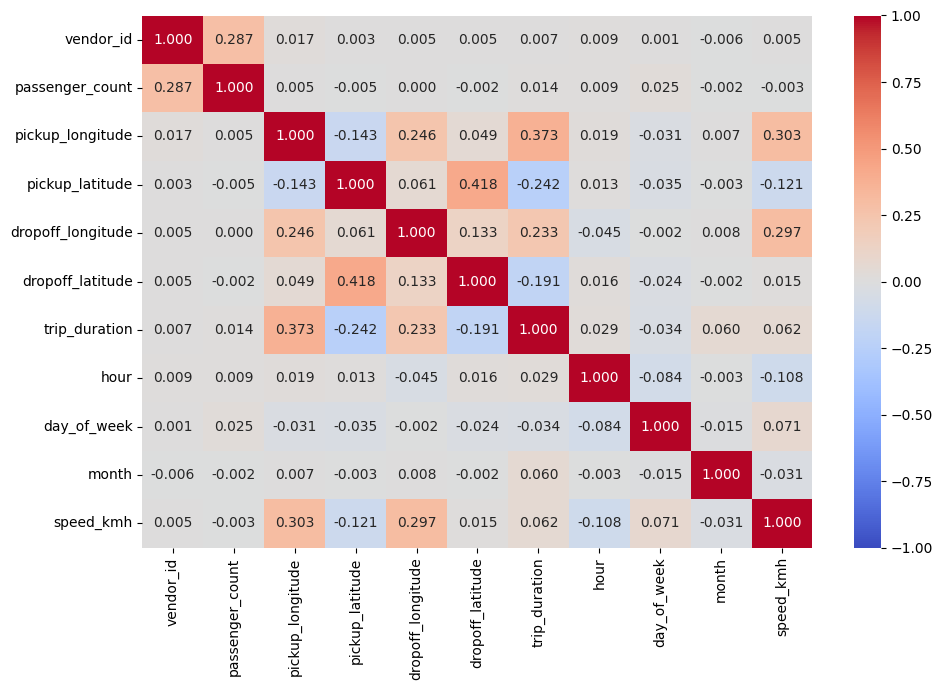

In [132]:
plt.figure(figsize=(10,7))
sns.heatmap(data=num_feature.corr(),cmap='coolwarm',vmin=-1,vmax=1,annot=True,fmt=".3f")
plt.tight_layout()
plt.show()

In [135]:
df = df.drop(columns=['speed_kmh'])

In [136]:
clean_df=df

In [137]:
clean_df.to_csv('data/dataset_clean.csv', index=False)